In [1]:
from sklearn.datasets import load_iris

data = load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [2]:
X = data.data
y = data.target

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=99
)

In [6]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=1)
clf

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = clf.predict(X_test)
y_pred

array([2, 0, 1, 2, 0, 1, 1, 2, 0, 2, 2, 1, 2, 1, 2, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 2, 0, 0, 2, 1, 2, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 1, 1, 2, 2,
       1])

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9555555555555556

In [11]:
param_grid = {
    "max_depth": range(1, 10, 1),
    "min_samples_leaf": range(1, 20, 2),
    "min_samples_split": range(2, 20, 2),
    "criterion": ["entropy", "gini"],
}

In [12]:
tree = DecisionTreeClassifier(random_state=1)
tree

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, verbose=True)
grid_search

,estimator,DecisionTreeC...andom_state=1)
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': range(1, 10), 'min_samples_leaf': range(1, 20, 2), 'min_samples_split': range(2, 20, 2)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [15]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


,estimator,DecisionTreeC...andom_state=1)
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': range(1, 10), 'min_samples_leaf': range(1, 20, 2), 'min_samples_split': range(2, 20, 2)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [16]:
grid_search.best_score_

np.float64(0.9714285714285715)

In [17]:
grid_search.best_estimator_

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
tree_clf = grid_search.best_estimator_

[Text(0.4, 0.9, 'petal width (cm) <= 0.75\nentropy = 1.581\nsamples = 105\nvalue = [38, 32, 35]\nclass = setosa'),
 Text(0.2, 0.7, 'entropy = 0.0\nsamples = 38\nvalue = [38, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.6, 0.7, 'petal width (cm) <= 1.75\nentropy = 0.999\nsamples = 67\nvalue = [0, 32, 35]\nclass = virginica'),
 Text(0.5, 0.8, '  False'),
 Text(0.4, 0.5, 'petal length (cm) <= 4.95\nentropy = 0.503\nsamples = 36\nvalue = [0, 32, 4]\nclass = versicolor'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 30\nvalue = [0, 30, 0]\nclass = versicolor'),
 Text(0.6, 0.3, 'petal width (cm) <= 1.55\nentropy = 0.918\nsamples = 6\nvalue = [0, 2, 4]\nclass = virginica'),
 Text(0.4, 0.1, 'entropy = 0.0\nsamples = 3\nvalue = [0, 0, 3]\nclass = virginica'),
 Text(0.8, 0.1, 'entropy = 0.918\nsamples = 3\nvalue = [0, 2, 1]\nclass = versicolor'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 31\nvalue = [0, 0, 31]\nclass = virginica')]

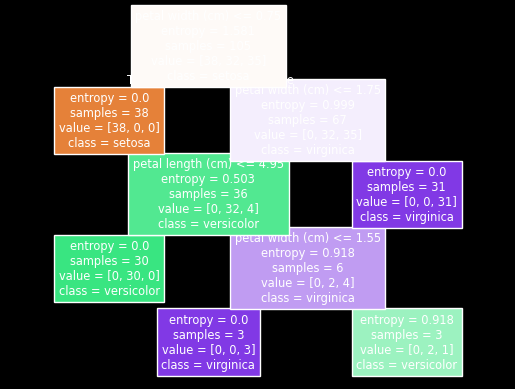

In [25]:
from sklearn.tree import plot_tree

plot_tree(
    tree_clf,
    filled=True,
    feature_names=data.feature_names,
    class_names=data.target_names,
)